In [1]:
import earthaccess
import os
import warnings
import csv
from osgeo import gdal
import numpy as np
import math
import rasterio as rio
import xarray as xr
import holoviews as hv
import hvplot.xarray
import netCDF4 as nc
#import cv2 as cv

import glob
import sys
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import rasterio
from rasterio.transform import Affine
from scipy import linalg
from lxml import etree
from scipy.ndimage import gaussian_filter, binary_erosion, binary_dilation
from skimage.transform import hough_line, hough_line_peaks

wav_min = 418
wav_max = 492
bin_size = 1
polydeg = 3
sys.path.append('../')
from config import CONFIG, POWER_PLANTS, CROSS_SECTIONS, LOCS
sys.path.append('../../EMIT-Data-Resources/python/modules/')
from emit_tools import emit_xarray, ortho_xr
help(emit_xarray)

Help on function emit_xarray in module emit_tools:

emit_xarray(filepath, ortho=False, qmask=None, unpacked_bmask=None)
    This function utilizes other functions in this module to streamline opening an EMIT dataset as an xarray.Dataset.
    
    Parameters:
    filepath: a filepath to an EMIT netCDF file
    ortho: True or False, whether to orthorectify the dataset or leave in crosstrack/downtrack coordinates.
    qmask: a numpy array output from the quality_mask function used to mask pixels based on quality flags selected in that function. Any non-orthorectified array with the proper crosstrack and downtrack dimensions can also be used.
    unpacked_bmask: a numpy array from  the band_mask function that can be used to mask band-specific pixels that have been interpolated.
    
    Returns:
    out_xr: an xarray.Dataset constructed based on the parameters provided.



In [2]:
imfns = glob.glob(f"{CONFIG['data_folder']}/RIYADH_PLANT_9/*RAD*")
# fn = '/Volumes/T9/EMIT-NOX/data/EMIT/LOC_24.732_46.704/EMIT_L1B_RAD_001_20220903T051912_2224604_012.nc'
print(len(imfns))
fn = imfns[-1]
fn = '/Volumes/T9/EMIT-NOX/data/EMIT/LOC_33.942_-118.404/EMIT_L1B_RAD_001_20220828T174405_2224012_007.nc'
fn = '/Volumes/T9/EMIT-NOX/data/EMIT/LOC_33.942_-118.404/EMIT_L1B_RAD_001_20230728T214106_2320914_002.nc'
# fn = '/Volumes/T9/EMIT-NOX/data/EMIT/XAI_CENTER/EMIT_L1B_RAD_001_20240330T183753_2409012_022.nc'
ds = emit_xarray(fn)
fn

17


'/Volumes/T9/EMIT-NOX/data/EMIT/LOC_33.942_-118.404/EMIT_L1B_RAD_001_20230728T214106_2320914_002.nc'

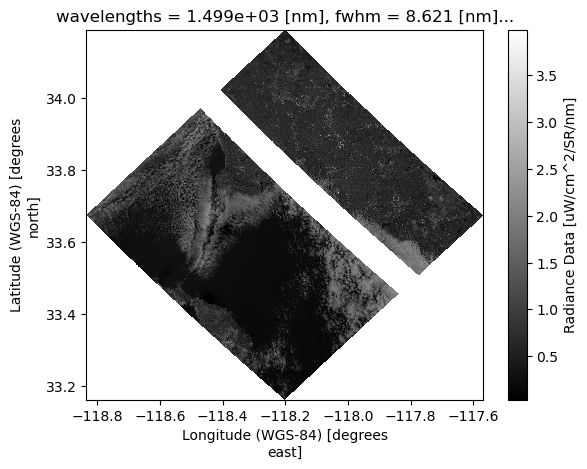

In [3]:
ortho_full = ortho_xr(ds)

ortho_rad = ortho_full.sel(wavelengths=1500, method='nearest')['radiance']
ortho_rad = ortho_rad.where(ortho_rad >= -8000)
ortho_rad.plot(cmap='gray')

In [5]:
def gaussian_kernel(x, mu, fwhm_nm):
    """
    Create normalized Gaussian kernel with standard deviation sigma (nm) based on sigma = FWHM/sqrt(2log2)
    """
    # Define standard deviation sigma
    sigma = fwhm_nm / (2.0 * np.sqrt(2.0 * np.log(2.0)))
    # Create kernel
    k = np.exp(-0.5 * ((x - mu) / sigma)**2)
    # Normalize kernel to area = 1
    k /= np.trapz(k, x, dx=0.01)
    return k

def convolve_to_sensor_grid(xs_wav_nm, xs, sensor_wav_nm, sensor_fwhm_nm):
    """
    Convolve high-res cross-section xs_sigma(xs_wav_nm) to sensor grid using per-band Gaussian SRF.
    Returns array of length len(sensor_wav_nm).
    """
    out = np.zeros_like(sensor_wav_nm, dtype=float)
    for i, (mu, fwhm) in enumerate(zip(sensor_wav_nm, sensor_fwhm_nm)):
        # Create normalized Gaussian kernel
        k = gaussian_kernel(xs_wav_nm, mu, fwhm)
        # Apply kernel to absorption cross-section spectrum
        out[i] = np.trapz(k * xs, xs_wav_nm, dx=0.01)
    return out

In [6]:
# Get NO2 absorption cross-sections @ 220K from Vandaele et al. (1998)
# Following TROPOMI NO2 ATBD: https://sentinel.esa.int/documents/247904/2476257/sentinel-5p-tropomi-atbd-no2-data-products
# Data reference: http://spectrolab.aeronomie.be/no2.htm
no2_cross_sections_path = CROSS_SECTIONS['NOX']
no2_cross_sections = pd.read_csv(
    no2_cross_sections_path,
    sep=" ",
    usecols=[3, 4],
    names=["vacuum_wavenumber_cm-1", "cross_section_cm^2/molecule_@220K"],
)
# add wavelength column (nm)
no2_cross_sections["vacuum_wavelength_nm"] = 1e7 / no2_cross_sections["vacuum_wavenumber_cm-1"].values

emit_spec_wlen = ds["wavelengths"].to_numpy().astype(np.float64)
emit_spec_fwhm = ds["fwhm"].to_numpy().astype(np.float64)

no2_cross_sections_conv = convolve_to_sensor_grid(no2_cross_sections["vacuum_wavelength_nm"], 
                                                  no2_cross_sections["cross_section_cm^2/molecule_@220K"],
                                                  emit_spec_wlen,
                                                  emit_spec_fwhm)

# Select bands and convolved cross-sections in fitting window
window_sel = (emit_spec_wlen >= wav_min) & (emit_spec_wlen <= wav_max)
emit_vnir_spectral_bands_fitting_window = emit_spec_wlen[window_sel].copy()
no2_cross_sections_conv_fitting_window = no2_cross_sections_conv[window_sel].copy()

desired_bands = emit_vnir_spectral_bands_fitting_window
desired_bands

array([418.05358887, 425.47213745, 432.8927002 , 440.31726074,
       447.74279785, 455.17034912, 462.59887695, 470.03039551,
       477.46292114, 484.89743042])

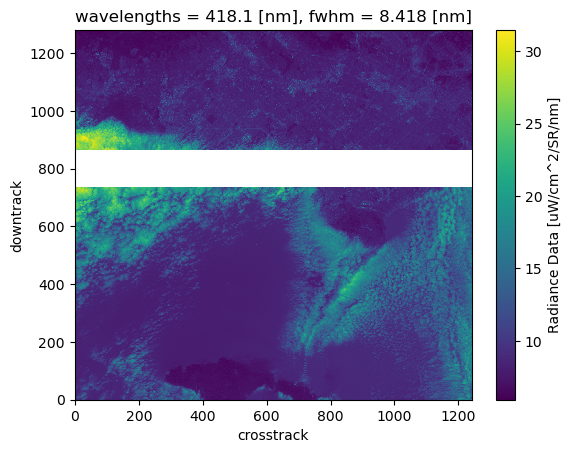

In [7]:
ds.sel(wavelengths=desired_bands[0], method='nearest')['radiance'].plot()

In [8]:
emit_windowed = ds.sel(wavelengths=desired_bands, method='nearest')
emit_windowed = emit_windowed.coarsen(downtrack=bin_size, crosstrack=bin_size, boundary="trim").mean()

We fit the differential optical depth:

$D(\lambda) = \ln\frac{I_{ref}(\lambda)}{I(\lambda)} = \sum_k a_k\,\sigma_k^{*}(\lambda) + P_m(\lambda) + C_{ring}\,R(\lambda) + \varepsilon $


where $\sigma_k^{*}$ are SRF‑convolved cross‑sections, $P_m$ is a degree‑`poly_degree` polynomial, and $R$ is the Ring pseudo‑absorber.

In [9]:
RING = None

def build_design_matrix(emit, xs_conv, include_ring=False, include_inverse_spectrum=False, jj=None, ii=None, fit_shift=False, fit_stretch=False, poly_degree=polydeg):
    wav = emit['wavelengths']/1e3
    # Stack species columns
    cols = []
    names = []
    #for name, v in ["NO2", xs_conv]:
    #    cols.append(v)
    #    names.append(name)
    cols.append(xs_conv*1e19)
    names.append("NO2")

    if include_ring:
        cols.append(RING if RING is not None else np.zeros_like(wav))
        names.append('RING')

    # Polynomial baseline
    Xp = np.vstack([wav**i for i in range(poly_degree+1)]).T  # (nband, poly_degree+1)
    for i in range(poly_degree+1):
        cols.append(Xp[:, i])
        names.append(f'poly_{i}')

    if include_inverse_spectrum:
        cols.append(1/emit["radiance"][:,jj,ii])
        names.append("inverse_spectrum")

    A = np.vstack(cols).T  # (nband, n_par)

    return A, names

A, names = build_design_matrix(
    emit_windowed, no2_cross_sections_conv_fitting_window,
)


len(names), names

(5, ['NO2', 'poly_0', 'poly_1', 'poly_2', 'poly_3'])

In [51]:
def doas_fit_pixel(I_ref, I_meas, A, weight=None):
    # Differential optical depth
    # print("IR:", I_ref) 
    # print("IM: ", I_meas)
    D = np.log(I_ref / I_meas)
    if weight is None:
        W = np.eye(len(D))
    else:
        w = np.clip(weight, 1e-12, None)
        W = np.diag(w)
    # Solve normal equations (A^T W A) x = A^T W D
    AtW = A.T @ W
    N = AtW @ A
    # print("D:", D)
    y = AtW @ D
    x = linalg.lstsq(N, y)[0]
    # Residuals & covariance estimate
    D_fit = A @ x
    r = D - D_fit
    dof = max(len(D) - A.shape[1], 1)
    s2 = (r @ r) / dof
    # print(s2.values, np.linalg.pinv(N))
    cov = s2 * linalg.pinv(N)
    return x, cov, r, s2

def precompute_column_stats(radiance_yxn, eligible_mask=None):
    """
    radiance_yxn: (ny, nx, nband)
    eligible_mask: (ny, nx) True => include; default = finite across all bands
    Returns dict with per-column sums (nband, nx) and counts (nx,).
    """
    if eligible_mask is None:
        eligible_mask = np.isfinite(radiance_yxn).all(axis=2)  # (ny, nx)

    m = eligible_mask[..., None]                              # (ny, nx, 1)
    sum_per_col = np.nansum(radiance_yxn * m, axis=0).T            # (nband, nx)
    cnt_per_col = eligible_mask.sum(axis=0).astype(np.int32)  # (nx,)

    return {
        "sum_per_col":   sum_per_col,
        "cnt_per_col":   cnt_per_col,
        "eligible_mask": eligible_mask
    }

def column_ref_for_pixel(stats, radiance, j, i, exclude_self=True):
    """
    Mean spectrum for column i (optionally excluding pixel (j,i) if it was eligible).
    """
    sum_c = stats["sum_per_col"][:, i]
    cnt_c = int(stats["cnt_per_col"][i])

    if exclude_self and stats["eligible_mask"][j, i]:
        return (sum_c - radiance[j, i, :]) / max(cnt_c - 1, 1)
    else:
        return sum_c / max(cnt_c, 1)

def run_doas_scene_vertical_striping(emit, A, names, plume_mask=None, userad=False):
    if not userad:
        rad = emit['radiance'].to_numpy()
    else:
        rad = emit

    idxs = np.where(~np.isnan(rad[:,:,0]))
    npoints = len(idxs[0])
    ny, nx, nband = rad.shape

    no2_cols = [i for i, n in enumerate(names) if n.startswith('NO2')]
    stats = precompute_column_stats(rad, eligible_mask=plume_mask)
    
    dscd = np.full((ny, nx), np.nan, dtype=float)
    dscd_err = np.full((ny, nx), np.nan, dtype=float)
    rms = np.full((ny, nx), np.nan, dtype=float)

    for p_idx in range(npoints):
        j = idxs[0][p_idx]
        i = idxs[1][p_idx]

        row = rad[j, :, :]
        I_meas = row[i, :]

        ref_spec = column_ref_for_pixel(stats, rad, j, i)
        
        if not np.isfinite(I_meas).any() or np.isnan(I_meas).any():
            continue
        
        # try:
        x, cov, r, s2 = doas_fit_pixel(ref_spec, I_meas, A)
        # Sum NO2 components if multiple temps are included
        dscd_val = np.nansum([x[k] for k in no2_cols])
        # Error as sqrt of sum of variances (approx), ignoring covariance between NO2 temps
        dscd_var = np.nansum([cov[k, k] for k in no2_cols])
        dscd[j, i] = dscd_val
        dscd_err[j, i] = np.sqrt(max(dscd_var, 0))
        rms[j, i] = np.sqrt(np.mean(r**2))
        # except Exception as e:
            # print(e)
            # continue

    out = {
        "dSCD": dscd,
        "dSCD_err": dscd_err,
        "rms": rms,
        "names": names
    }
    return out

In [53]:
DOAS0 = run_doas_scene_vertical_striping(emit_windowed, A, names)
for k, v in DOAS0.items():
    if isinstance(v, np.ndarray):
        print(k, v.shape)
    else:
        print(k, type(v))

dSCD (1280, 1242)
dSCD_err (1280, 1242)
rms (1280, 1242)
names <class 'list'>


In [54]:
DOAS0['dSCD']

array([[-0.0061422 ,  0.00489571, -0.00653654, ..., -0.00301241,
        -0.00093505,  0.01042263],
       [-0.0048578 , -0.00047403, -0.00013086, ..., -0.00409296,
         0.00481439,  0.00261598],
       [ 0.00435594,  0.00216334, -0.0079456 , ..., -0.005666  ,
        -0.00165286,  0.00070423],
       ...,
       [ 0.01221856,  0.000422  , -0.00900719, ...,  0.00648188,
        -0.01035151, -0.00518978],
       [-0.00589396, -0.00414609, -0.00343638, ..., -0.00129277,
        -0.01530485, -0.01700699],
       [ 0.00596032, -0.00566713, -0.00383007, ...,  0.0017005 ,
         0.00325532, -0.00397321]])

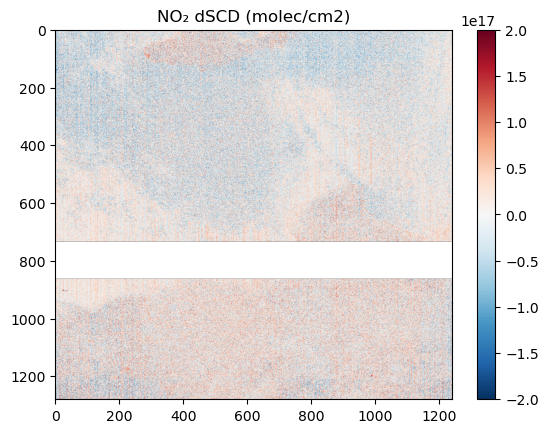

In [55]:
def imshow_quick(a, title, vmin=None, vmax=None):
    plt.figure()
    plt.imshow(a, vmin=vmin, vmax=vmax, origin='upper', cmap="RdBu_r", aspect='auto') # vmin=-2e-39, vmax=2e-39,
    plt.title(title)
    plt.colorbar()
    # plt.show()

imshow_quick(DOAS0['dSCD']*1e19, 'NO₂ dSCD (molec/cm2)', vmin=-2e17, vmax=2e17)

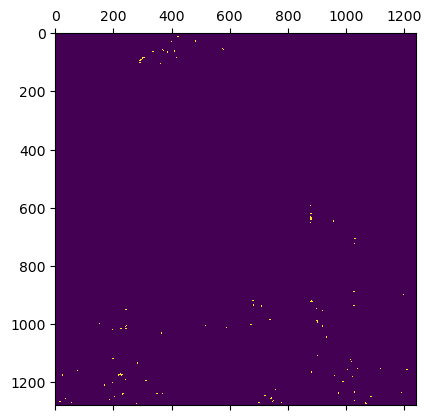

In [56]:
# Threshold mask
threshold = np.nanpercentile(np.abs(DOAS0['dSCD']), 95)
full_plume_mask = DOAS0['dSCD'] > threshold
full_plume_mask = full_plume_mask.astype(np.uint8)

# Morphological operations (dilate → erode → dilate)
# These use a default 3x3 structuring element if none is provided
full_plume_mask = binary_dilation(full_plume_mask, iterations=2)
full_plume_mask = binary_erosion(full_plume_mask, iterations=4)
full_plume_mask = binary_dilation(full_plume_mask, iterations=2)

# Convert boolean back to uint8 for visualization if desired
full_plume_mask = full_plume_mask.astype(np.uint8)

# Visualize
plt.matshow(full_plume_mask)
plt.show()

In [57]:
DOAS = run_doas_scene_vertical_striping(emit_windowed, A, names, plume_mask=1-full_plume_mask)
for k, v in DOAS.items():
    if isinstance(v, np.ndarray):
        print(k, v.shape)
    else:
        print(k, type(v))

dSCD (1280, 1242)
dSCD_err (1280, 1242)
rms (1280, 1242)
names <class 'list'>


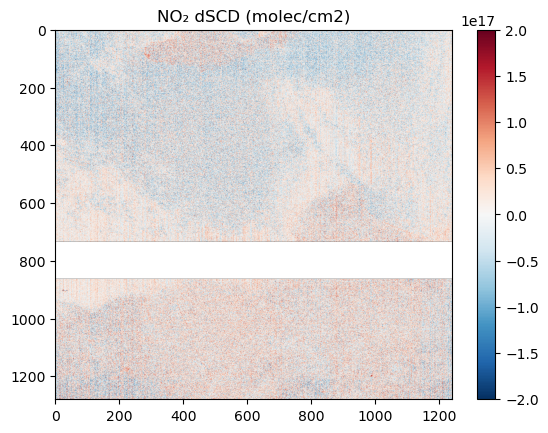

In [58]:
imshow_quick(DOAS['dSCD']*1e19, 'NO₂ dSCD (molec/cm2)', vmin=-2e17, vmax=2e17)

In [59]:
# choose a wavelength value (use the appropriate one for your product)
ds_nox = ds.copy()

wl_val = float(ds["wavelengths"].isel(wavelengths=0))  # or a specific value

dscd_da = xr.DataArray(
    DOAS['dSCD'].astype('float32')[..., None],  # -> (downtrack, crosstrack, 1)
    dims=("downtrack", "crosstrack", "wavelengths"),
    coords={
        "downtrack": ds["downtrack"],
        "crosstrack": ds["crosstrack"],
        "wavelengths": [wl_val],
    },
    name="dSCD",
    attrs={
        "long_name": "Differential Slant Column Density (single band)",
        "units": "molec cm^-2",
    },
)

ds_nox = ds_nox.assign(dSCD=dscd_da)
ds_nox

<xarray.Dataset> Size: 4GB
Dimensions:            (downtrack: 1280, crosstrack: 1242, wavelengths: 285,
                        ortho_y: 1895, ortho_x: 2335)
Coordinates:
  * downtrack          (downtrack) int64 10kB 0 1 2 3 4 ... 1276 1277 1278 1279
  * crosstrack         (crosstrack) int64 10kB 0 1 2 3 4 ... 1238 1239 1240 1241
  * wavelengths        (wavelengths) float32 1kB 381.0 388.4 ... 2.493e+03
    lon                (downtrack, crosstrack) float64 13MB ...
    lat                (downtrack, crosstrack) float64 13MB ...
    elev               (downtrack, crosstrack) float64 13MB -37.29 ... 385.0
    glt_x              (ortho_y, ortho_x) float64 35MB 0.0 0.0 0.0 ... 0.0 0.0
    glt_y              (ortho_y, ortho_x) float64 35MB 0.0 0.0 0.0 ... 0.0 0.0
    fwhm               (wavelengths) float32 1kB 8.415 8.415 ... 8.807 8.809
Dimensions without coordinates: ortho_y, ortho_x
Data variables:
    radiance           (downtrack, crosstrack, wavelengths) float32 2GB 7.283...
    flat_field_update  (crosstrack, wavelengths) float32 1MB ...
    dSCD               (downtrack, crosstrack, wavelengths) float32 2GB -0.00...
Attributes: (12/39)
    ncei_template_version:             NCEI_NetCDF_Swath_Template_v2.0
    summary:                           The Earth Surface Mineral Dust Source ...
    keywords:                          Imaging Spectroscopy, minerals, EMIT, ...
    Conventions:                       CF-1.63
    sensor:                            EMIT (Earth Surface Mineral Dust Sourc...
    instrument:                        EMIT
    ...                                ...
    spatialResolution:                 0.000542232520256367
    spatial_ref:                       GEOGCS["WGS 84",DATUM["WGS_1984",SPHER...
    geotransform:                      [-1.18834329e+02  5.42232520e-04 -0.00...
    day_night_flag:                    Day
    title:                             EMIT L1B At-Sensor Calibrated Radiance...
    granule_id:                        EMIT_L1B_RAD_001_20230728T214106_23209...

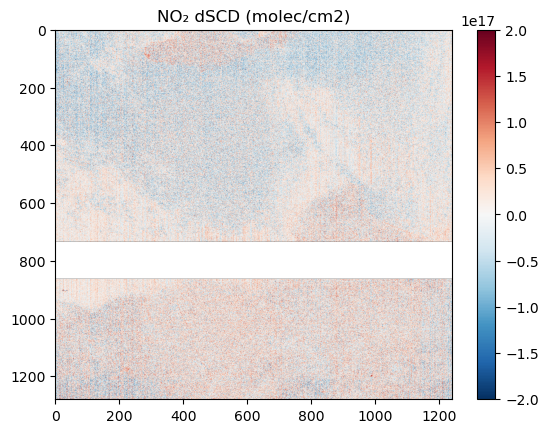

In [60]:
imshow_quick(np.array(ds_nox['dSCD'])[:,:,0]*1e19, 'NO₂ dSCD (molec/cm2)', vmin=-2e17, vmax=2e17)

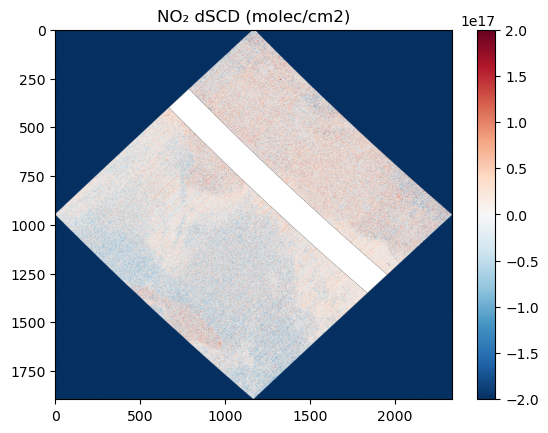

In [61]:
# 1) Orthorectify the whole dataset (uses GLT, geotransform, and spatial_ref inside the ds)
ortho_ds = ortho_xr(ds_nox)  # nox_ds should be your non-orthorectified dataset
imshow_quick(np.array(ortho_ds['dSCD'])[:,:,0]*1e19, 'NO₂ dSCD (molec/cm2)', vmin=-2e17, vmax=2e17)

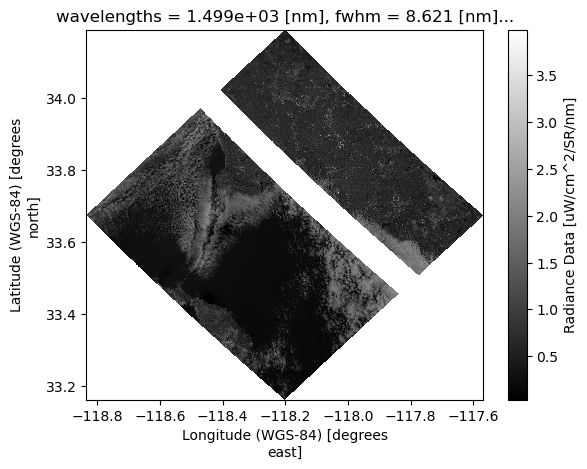

In [62]:
ortho_rad.plot(cmap='gray')

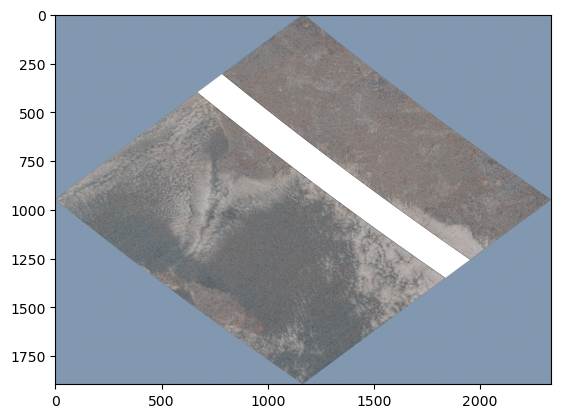

In [63]:
vmin=-2e17
vmax=2e17

plt.figure()
plt.imshow(ortho_rad, cmap='gray')
plt.imshow(np.array(ortho_ds['dSCD'])[:,:,0]*1e19, alpha=0.5, vmin=vmin, vmax=vmax, origin='upper', cmap="RdBu_r", aspect='auto')

# plt.title(title)
# plt.colorbar()